 Exercise 2.8(d) Write a Python program to pose the SPARQL queries to the Wikidata SPARQL server and to visualize the result.



 This notebook demonstrates how to execute a SPARQL query against the

 Wikidata Query Service from Python, and then visualize the results as a graph.



 We will:



 1. Connect to the Wikidata SPARQL endpoint.

 2. Execute a SPARQL query.

 3. Retrieve the results in JSON format.

 4. Convert the results into a more readable table.

 5. Visualize the results as a graph.

In [1]:
import requests
import time


 ## Specify the SPARQL Endpoint



 All queries are submitted to the Wikidata Query Service. The endpoint URL

 is stored in a constant so that it can be reused throughout the notebook.

In [2]:
WIKIDATA_SPARQL_URL = "https://query.wikidata.org/sparql"


 ## Execute a SPARQL Query



 The following helper function sends a SPARQL query to the Wikidata Query

 Service and returns the results as a Python dictionary obtained by parsing

 the JSON response.



 Because public web services may occasionally reject requests due to heavy

 load or temporary outages, the function automatically retries failed

 requests using exponential backoff.

In [3]:
def run_sparql(query: str):
    headers = {
        "Accept": "application/sparql-results+json",
        "User-Agent": "FinKG/1.0 (vchaudhri@acm.org)"
    }

    for attempt in range(5):
        try:
            response = requests.post(
                WIKIDATA_SPARQL_URL,
                data={"query": query},
                headers=headers,
                timeout=120
            )

            response.raise_for_status()
            return response.json()

        except requests.exceptions.HTTPError as e:
            status = e.response.status_code

            if status not in [429, 502, 503, 504]:
                raise

            wait = 2 ** attempt

            print(
                f"HTTP {status}. "
                f"Retry {attempt+1}/5 in {wait} seconds"
            )

            time.sleep(wait)

    raise RuntimeError("SPARQL query failed after 5 retries")


 ## Define a SPARQL Query



 We developed the following query in the previous exercise. It retrieves a set of entities from Wikidata, along with their properties and values.

In [4]:
test_query = """
SELECT ?s ?sLabel ?pEntityLabel ?o ?oLabel
WHERE {
  {
    VALUES (?s ?p ?pEntity ?o) {
      (wd:Q30      wdt:P361 wd:P361 wd:Q49)
      (wd:Q9125    wdt:P190 wd:P190 wd:Q488134)
      (wd:Q9125    wdt:P361 wd:P361 wd:Q690149)
      (wd:Q488134  wdt:P17  wd:P17  wd:Q30)
    }

    ?s ?p ?o .
  }

  UNION

  {
    VALUES (?s ?p ?pEntity ?o) {
      (wd:Q690149 wdt:P361 wd:P361 wd:Q39)
    }

    ?s wdt:P361+ ?o .
  }

  SERVICE wikibase:label {
    bd:serviceParam wikibase:language "en".
  }
}
"""


 ## Execute the Query



 The query is submitted to the Wikidata Query Service, which returns the

 results as a JSON document. The variable `result` stores the parsed JSON

 representation.

In [5]:
result = run_sparql(test_query)


 ## Extract the Query Results



 Each row of the SPARQL result is represented as a dictionary whose entries

 correspond to the variables in the `SELECT` clause.



 The following code extracts the subject, property, and object labels, along

 with the corresponding Wikidata URIs.

In [6]:
rows = []

for binding in result["results"]["bindings"]:
    rows.append({
        "Subject": binding["sLabel"]["value"],
        "Property": binding["pEntityLabel"]["value"],
        "Object": binding["oLabel"]["value"],
        "Subject URI": binding["s"]["value"],
        "Object URI": binding["o"]["value"],
    })


 ## Display the Results



 The following code computes appropriate column widths and prints the query

 results as a neatly aligned table.

In [7]:
headers = ["Subject", "Property", "Object"]

widths = {
    h: max(len(h), max(len(r[h]) for r in rows))
    for h in headers
}

print(
    f"{headers[0]:<{widths['Subject']}}  "
    f"{headers[1]:<{widths['Property']}}  "
    f"{headers[2]:<{widths['Object']}}"
)

print(
    f"{'-'*widths['Subject']}  "
    f"{'-'*widths['Property']}  "
    f"{'-'*widths['Object']}"
)

for r in rows:
    print(
        f"{r['Subject']:<{widths['Subject']}}  "
        f"{r['Property']:<{widths['Property']}}  "
        f"{r['Object']:<{widths['Object']}}"
    )


Subject                   Property                     Object                  
------------------------  ---------------------------  ------------------------
United States             part of                      North America           
Winterthur                twinned administrative body  Ontario                 
Winterthur                part of                      Zurich metropolitan area
Ontario                   country                      United States           
Zurich metropolitan area  part of                      Switzerland             


 ## Visualize the Query Results as a Graph



 The query results represent RDF triples of the form



 > subject —property→ object



 We can visualize these triples as a directed graph in which:



 - each entity is represented by a node, and

 - each property is represented by a labeled directed edge.



 The following code uses the NetworkX library to construct and display the graph.

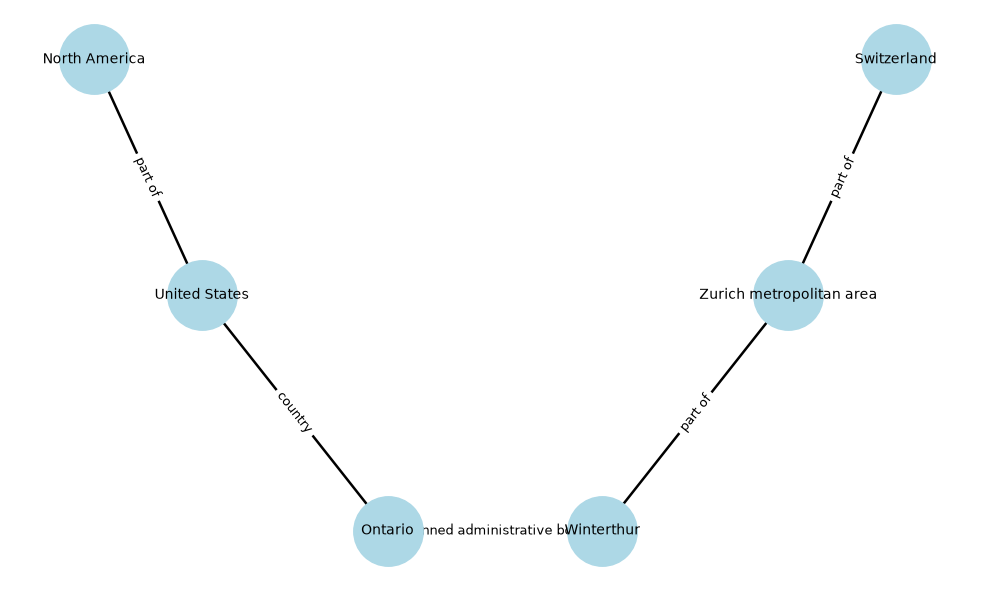

In [8]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

for r in rows:
    G.add_edge(
        r["Subject"],
        r["Object"],
        label=r["Property"]
    )

plt.figure(figsize=(10, 6))

# Compute node positions using a force-directed layout.
# pos = nx.spring_layout(G, seed=42)

# pos = nx.kamada_kawai_layout(G)


#pos = nx.circular_layout(G)

#pos = nx.shell_layout(G)

pos = nx.spectral_layout(G)

# Draw nodes.
nx.draw_networkx_nodes(
    G,
    pos,
    node_size=2500,
    node_color="lightblue"
)

# Draw edges.
nx.draw_networkx_edges(
    G,
    pos,
    arrows=True,
    arrowstyle="-|>",
    arrowsize=18,
    width=1.8
)

# Draw node labels.
nx.draw_networkx_labels(
    G,
    pos,
    font_size=10
)

# Draw edge labels.
edge_labels = nx.get_edge_attributes(G, "label")
nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=9
)

plt.axis("off")
plt.tight_layout()
plt.show()
